<a href="https://colab.research.google.com/github/tegarpng/Projek-Kelompok-29/blob/main/Percobaan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: muhammadtegarbijanta
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data


100%|██████████| 151M/151M [00:01<00:00, 87.6MB/s]


In [36]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [92]:
import os

dataset_dir = './brain-tumor-mri-data/brain-tumor-mri-dataset'

target_classes = ['glioma', 'notumor']

MAX_IMAGES_PER_CLASS = 300

X_data = []
y_labels = []
file_name = []

# Loop langsung ke folder kelas target
for label in target_classes:
    class_folder_path = os.path.join(dataset_dir, label)

    # Pastikan foldernya memang ada
    if os.path.exists(class_folder_path):
        # Ambil semua list file di dalam folder tersebut
        all_files = os.listdir(class_folder_path)

        # Saring hanya file gambar
        image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Batasi jumlah file yang akan diambil menggunakan slicing [ : BATAS ]
        limited_image_files = image_files[:MAX_IMAGES_PER_CLASS]

        print(f"Mengambil {len(limited_image_files)} gambar dari kelas: {label}")

        # Proses membaca gambar yang sudah dibatasi
        for file in limited_image_files:
            path = os.path.join(class_folder_path, file)

            img = cv2.imread(path)
            if img is not None:

                # Konversi BGR ke RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                img = cv2.resize(img, (256, 256))

                X_data.append(img)
                y_labels.append(label)
                file_name.append(file)

# Konversi hasil akhir ke Numpy Array
X_data = np.array(X_data)
y_labels = np.array(y_labels)

print("\n--- Hasil Akhir ---")
print("Shape X_data (Gambar) :", X_data.shape)
print("Shape y_labels (Label):", y_labels.shape)
print("Label unik yang tersimpan:", np.unique(y_labels))

Mengambil 300 gambar dari kelas: glioma
Mengambil 300 gambar dari kelas: notumor

--- Hasil Akhir ---
Shape X_data (Gambar) : (600, 256, 256)
Shape y_labels (Label): (600,)
Label unik yang tersimpan: ['glioma' 'notumor']


In [32]:
def median(image, rowkernel, columnkernel):
    row, column = int(rowkernel/2), int(columnkernel/2)
    image_pad = np.pad(image, [(row, row), (column, column)], mode="edge")
    result = np.zeros(image.shape)

    for i in range(row, image.shape[0] + row):
        for j in range(column, image.shape[1] + column):
            submatrix = image_pad[i-row:i+row+1, j-column:j+column+1]
            result[i-row, j-column] = np.median(submatrix)

    return result

In [23]:
def ekualisasi(citra):
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)

    # Hitung histogram
    for i in range(height):
        for j in range(width):
            hist[citra[i][j]] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(int)

    # Terapkan ke setiap pixel
    hasil = np.zeros_like(citra)
    for i in range(height):
        for j in range(width):
            hasil[i][j] = cdf_normal[citra[i][j]]

    return hasil

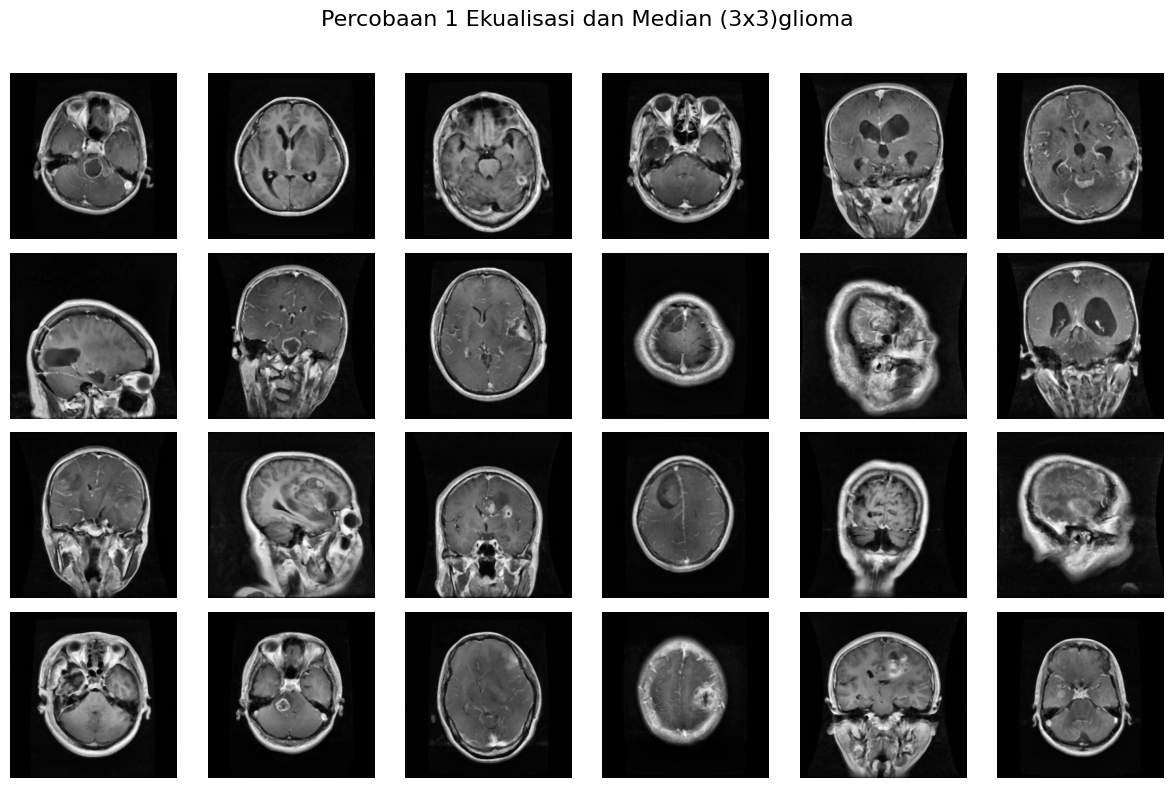

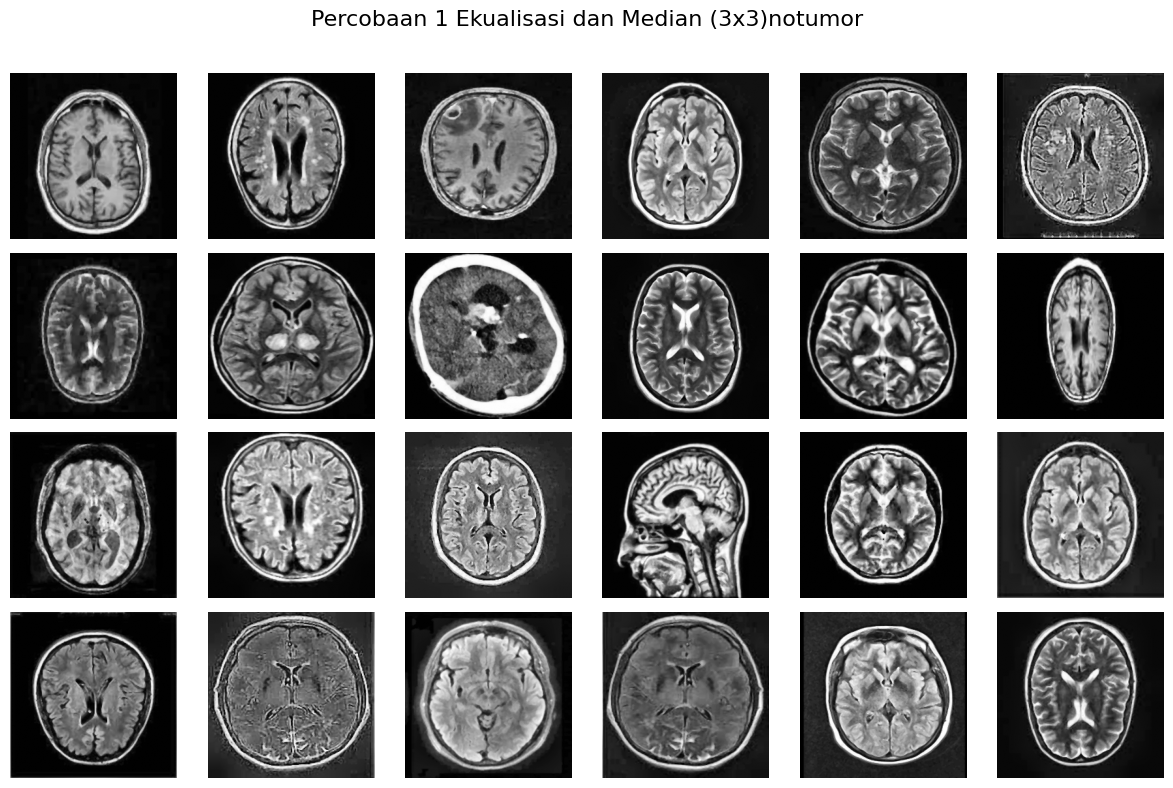

In [67]:
def percobaan1(img):
    clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8))

    equalized = clahe.apply(img)
    img_equal = median(equalized, 3, 3)
    return img_equal

dataPreprocessed = [percobaan1(img) for img in X_data]

unique_labels = sorted(set(y_labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(y_labels) if l == label]

    # Buat grid 7x12 (cukup untuk 84 gambar, 7*12 = 84)
    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Percobaan 1 Ekualisasi dan Median (3x3){label}', fontsize=16)

    for k in range(24):
        plt.subplot(4, 6, k + 1)
        plt.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # beri ruang untuk judul
    plt.show()

In [78]:
file_name = ['glioma dan notumor']
for i in range(len(dataPreprocessed)):
    dataPreprocessed[i] = dataPreprocessed[i].astype(np.uint8)

print(len(dataPreprocessed))
# for i in range(len(X_data)): # Loop through each image and do preprocessing

600


In [79]:
def glcm(img, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(img, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [80]:

def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [81]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [82]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [83]:

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(dataPreprocessed)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)


for i in range(len(dataPreprocessed)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(dataPreprocessed)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(dataPreprocessed)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(dataPreprocessed)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(dataPreprocessed)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)


In [94]:
dataTable = {'Filename': file_name, 'Label': y_labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
display(hasilEkstrak)

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,gl-0567.jpg,glioma,134.564982,204.879523,95.323085,199.326644,0.676294,0.627548,0.678824,0.625318,...,0.107035,0.102187,0.326624,0.319694,0.327163,0.319667,0.972536,0.958262,0.980545,0.959393
1,gl-0401.jpg,glioma,156.795527,261.263391,142.793382,267.442860,0.673665,0.624281,0.685410,0.622244,...,0.075228,0.070462,0.274636,0.265726,0.274278,0.265448,0.970102,0.950263,0.972772,0.949087
2,gl-0163.jpg,glioma,179.199295,276.260069,141.412178,294.571088,0.592585,0.535392,0.596104,0.533146,...,0.067484,0.063272,0.258373,0.251569,0.259777,0.251540,0.975134,0.961711,0.980377,0.959173
3,gl-0852.jpg,glioma,167.760999,262.197724,129.531327,252.822684,0.638418,0.587260,0.643875,0.586756,...,0.097124,0.092377,0.308785,0.303934,0.311647,0.303935,0.971558,0.955626,0.978041,0.957213
4,gl-0219.jpg,glioma,172.086244,240.219654,106.620205,259.819685,0.553438,0.481732,0.554163,0.484985,...,0.047111,0.044144,0.214346,0.210048,0.217051,0.210105,0.967757,0.954996,0.980030,0.951324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,no-1544.jpg,notumor,288.175797,510.464468,281.075888,517.846890,0.661336,0.633724,0.669148,0.633125,...,0.304914,0.300776,0.551863,0.548381,0.552190,0.548430,0.973538,0.953232,0.974190,0.952556
596,no-1505.jpg,notumor,539.310447,1001.423760,521.801134,980.106390,0.361299,0.318565,0.367423,0.314453,...,0.023504,0.021988,0.153309,0.147964,0.153309,0.148285,0.960838,0.927241,0.962101,0.928790
597,no-0939.jpg,notumor,238.871783,373.951342,177.012102,380.718831,0.602034,0.567079,0.609401,0.566527,...,0.208767,0.204223,0.456084,0.452394,0.456910,0.451910,0.978132,0.965806,0.983795,0.965187
598,no-1549.jpg,notumor,217.010600,307.714479,119.265717,302.937670,0.678161,0.649137,0.690505,0.647575,...,0.298148,0.293024,0.542632,0.541305,0.546030,0.541317,0.971670,0.959900,0.984430,0.960522
